<h1><center>
DATA PRE-PROCESSING AND EXPLORATORY DATA ANALYSIS</center></h1>

## Performed on Global wide Cancer Patient's Data of year 2015 to 2024

<h3>Step-1: Data Understanding</h3>

#### Identifying the datset
1. The primary objective of this dataset is to analyze information related to cancer patients across different regions of the world. It can also be        used   to develop predictive models that estimate a patient’s condition or disease severity based on various input features.
2. The dataset consists of global cancer patient records and includes 15 distinct features, namely:
   Patient_ID, Age, Gender, Country_Region, Year, Genetic_Risk, Air_Pollution, Alcohol_Use, Smoking, Obesity_Level, Cancer_Type, Cancer_Stage,             Treatment_Cost_USD, Survival_Years, and Target_Severity_Score.
3. Each feature represents a specific demographic, environmental, lifestyle, medical, or clinical aspect of an individual patient’s record.

Note: This is a labelled dataset, making it suitable for supervised machine learning and predictive analysis tasks.

#### What does Target_Severity_Score represent?
1. The Target_Severity_Score acts as the output variable (Y) of the dataset.
2. It is a dependent variable whose value is influenced by all the other input features.
3. A higher Target_Severity_Score indicates greater disease severity, while a lower score reflects lesser severity.

<h3>Step-2: Data Inspection</h3>

In [266]:
#Importing the required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [267]:
# loading the dataset
df = pd.read_csv('global_cancer_patients_2015_2024.csv')

In [268]:
# Checking the Structure of the Dataset
# preview the top five records from dataset
df.head()

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71.0,Male,UK,2021.0,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34.0,Male,China,2021.0,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80.0,Male,Pakistan,2023.0,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40.0,Male,UK,2015.0,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43.0,Female,Brazil,2017.0,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62


In [269]:
# identifies the shape of the dataset (records, features)
df.shape

(50000, 15)

In [270]:
# Display the dataset  description for the each fearures 
df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  object 
 1   Age                    49993 non-null  float64
 2   Gender                 49993 non-null  object 
 3   Country_Region         49996 non-null  object 
 4   Year                   49992 non-null  float64
 5   Genetic_Risk           49993 non-null  float64
 6   Air_Pollution          49991 non-null  float64
 7   Alcohol_Use            49992 non-null  float64
 8   Smoking                49990 non-null  float64
 9   Obesity_Level          49994 non-null  float64
 10  Cancer_Type            49993 non-null  object 
 11  Cancer_Stage           49987 non-null  object 
 12  Treatment_Cost_USD     49994 non-null  float64
 13  Survival_Years         49996 non-null  float64
 14  Target_Severity_Score  49996 non-null  float64
dtypes:

In [271]:
# Gives Descriptive Statistics of numerical features
df.describe()

,Age,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
count,49993.000000,49992.000000,49993.000000,49991.000000,49992.000000,49990.000000,49994.000000,49994.000000,49996.000000,49996.000000
mean,54.420839,2019.480777,5.001696,5.009876,5.010816,4.989836,4.990985,52467.106608,5.006499,4.951233
std,20.224295,2.871424,2.885751,2.888493,2.888737,2.881588,2.894543,27363.570020,2.883299,1.199716
min,20.000000,2015.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5000.050000,0.000000,0.900000
25%,37.000000,2017.000000,2.500000,2.500000,2.500000,2.500000,2.500000,28686.545000,2.500000,4.120000
50%,54.000000,2019.000000,5.000000,5.000000,5.000000,5.000000,5.000000,52474.310000,5.000000,4.950000
75%,72.000000,2022.000000,7.500000,7.500000,7.500000,7.500000,7.500000,76231.465000,7.500000,5.780000
max,89.000000,2024.000000,10.000000,10.000000,10.000000,10.000000,10.000000,99999.840000,10.000000,9.160000


In [272]:
# To find and Count of the  Missing values of each feature in dataset
df.isnull().sum()

Patient_ID                0
Age                       7
Gender                    7
Country_Region            4
Year                      8
Genetic_Risk              7
Air_Pollution             9
Alcohol_Use               8
Smoking                  10
Obesity_Level             6
Cancer_Type               7
Cancer_Stage             13
Treatment_Cost_USD        6
Survival_Years            4
Target_Severity_Score     4
dtype: int64

<h3>Step-3: Data Cleaning</h3>

In [274]:
 # to check the datatype of each column
df.dtypes

Patient_ID                object
Age                      float64
Gender                    object
Country_Region            object
Year                     float64
Genetic_Risk             float64
Air_Pollution            float64
Alcohol_Use              float64
Smoking                  float64
Obesity_Level            float64
Cancer_Type               object
Cancer_Stage              object
Treatment_Cost_USD       float64
Survival_Years           float64
Target_Severity_Score    float64
dtype: object

In [275]:
# filling the Missing numerical values with their Median Values.
num_cols = ['Age','Year','Genetic_Risk','Air_Pollution',
    'Alcohol_Use', 'Smoking', 'Obesity_Level',
    'Treatment_Cost_USD', 'Survival_Years']
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [276]:
df[num_cols].isnull().sum()

Age                   0
Year                  0
Genetic_Risk          0
Air_Pollution         0
Alcohol_Use           0
Smoking               0
Obesity_Level         0
Treatment_Cost_USD    0
Survival_Years        0
dtype: int64

In [277]:
# filling the Missing Categrical values with their Mode Values.
from sklearn.impute import SimpleImputer
SI = SimpleImputer(strategy = 'most_frequent')
cat_cols = ['Gender','Country_Region','Cancer_Type','Cancer_Stage']
df[cat_cols] = SI.fit_transform(df[cat_cols])

In [278]:
df[cat_cols].isnull().sum()

Gender            0
Country_Region    0
Cancer_Type       0
Cancer_Stage      0
dtype: int64

In [279]:
#finding if there are any duplicated Patient ID's
df["Patient_ID"].duplicated().sum() 

0

In [280]:
# Dropping Duplicated Records 
df = df.drop_duplicates()

In [281]:
df.shape

(50000, 15)

In [282]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Patient_ID             50000 non-null  object 
 1   Age                    50000 non-null  float64
 2   Gender                 50000 non-null  object 
 3   Country_Region         50000 non-null  object 
 4   Year                   50000 non-null  float64
 5   Genetic_Risk           50000 non-null  float64
 6   Air_Pollution          50000 non-null  float64
 7   Alcohol_Use            50000 non-null  float64
 8   Smoking                50000 non-null  float64
 9   Obesity_Level          50000 non-null  float64
 10  Cancer_Type            50000 non-null  object 
 11  Cancer_Stage           50000 non-null  object 
 12  Treatment_Cost_USD     50000 non-null  float64
 13  Survival_Years         50000 non-null  float64
 14  Target_Severity_Score  49996 non-null  float64
dtypes:

In [283]:
# Changing the DataTypes of Age & Year columns 
df['Age']= df['Age'].astype(int)
df['Year']= df['Year'].astype(int)
df.head(2)

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65


<h3>Step-4: Outlier Handling </h3>

In [285]:
columns = ['Treatment_Cost_USD', 'Survival_Years', 'Target_Severity_Score']

In [286]:
#Using IQR are method to detect Outliers
Q1 = df[columns].quantile(0.25)
Q3 = df[columns].quantile(0.75)
IQR = Q3 - Q1

In [287]:
outliers = (df[columns] < (Q1 - 1.5 * IQR)) | (df[columns] > (Q3 + 1.5 * IQR))

In [288]:
outliers.sum()

Treatment_Cost_USD         0
Survival_Years             0
Target_Severity_Score    151
dtype: int64

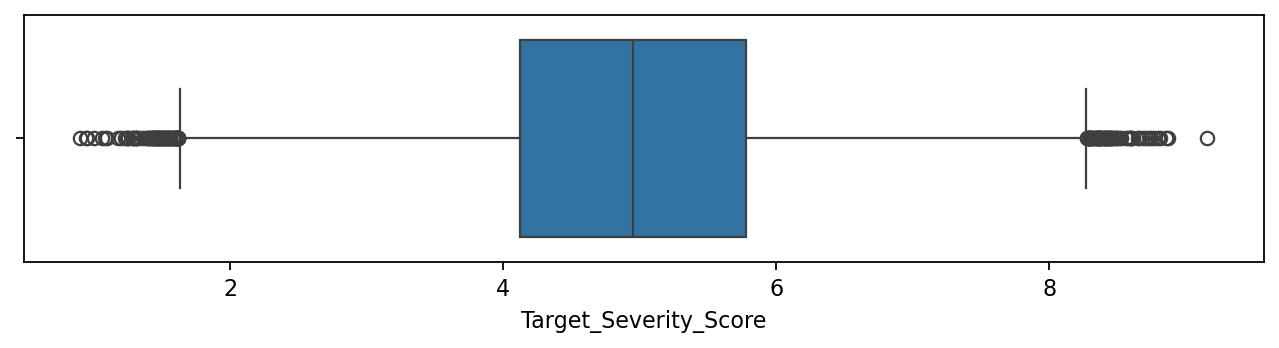

In [289]:
#plotting outliers using boxplot
plt.figure(figsize=(10,2), dpi=160)
sns.boxplot(data=df['Target_Severity_Score'], orient='h');

In [290]:
df.shape

(50000, 15)

In [291]:
#Removing Outliers
df = df[~(outliers).any(axis=1)]

In [292]:
df.shape

(49849, 15)

<h3>Step-5: Encoding Categorical Variables </h3>

In [294]:
df.head()

,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84
3,PT0000003,40,Male,UK,2015,1.7,2.9,4.8,3.5,2.7,Colon,Stage I,67446.25,1.6,3.12
4,PT0000004,43,Female,Brazil,2017,5.1,2.8,2.3,6.7,0.5,Skin,Stage III,77977.12,2.9,3.62


##### 1. Should Cancer_Stage use Integer Encoding? 
    No,Cancer_stage is ordinal data using one-hot encoding is better.
##### 2. Should Gender and Cancer_Type use One-Hot Encoding?
    Yes, Gender and Cancer_Type are ordinal data. One-hot encoding is better.

In [296]:
#Using One-Hot Encoding Method
df = pd.get_dummies(df, columns = ['Gender','Cancer_Stage','Cancer_Type'], drop_first= True)

In [297]:
# newly created features contain boolean values
df.info() 

<class 'pandas.core.frame.DataFrame'>
Index: 49849 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Patient_ID              49849 non-null  object 
 1   Age                     49849 non-null  int32  
 2   Country_Region          49849 non-null  object 
 3   Year                    49849 non-null  int32  
 4   Genetic_Risk            49849 non-null  float64
 5   Air_Pollution           49849 non-null  float64
 6   Alcohol_Use             49849 non-null  float64
 7   Smoking                 49849 non-null  float64
 8   Obesity_Level           49849 non-null  float64
 9   Treatment_Cost_USD      49849 non-null  float64
 10  Survival_Years          49849 non-null  float64
 11  Target_Severity_Score   49845 non-null  float64
 12  Gender_Male             49849 non-null  bool   
 13  Gender_Other            49849 non-null  bool   
 14  Cancer_Stage_Stage I    49849 non-null  boo

In [298]:
# Converting Boolean values into integer values 
bool_col = ['Gender_Male','Gender_Other','Cancer_Stage_Stage I','Cancer_Stage_Stage II','Cancer_Stage_Stage III','Cancer_Stage_Stage IV',
            'Cancer_Type_Cervical','Cancer_Type_Colon','Cancer_Type_Leukemia','Cancer_Type_Liver','Cancer_Type_Lung','Cancer_Type_Prostate',
            'Cancer_Type_Skin']            
for i in bool_col:
 df[i] = df[i].astype(int)

In [299]:
df[bool_col].dtypes

Gender_Male               int32
Gender_Other              int32
Cancer_Stage_Stage I      int32
Cancer_Stage_Stage II     int32
Cancer_Stage_Stage III    int32
Cancer_Stage_Stage IV     int32
Cancer_Type_Cervical      int32
Cancer_Type_Colon         int32
Cancer_Type_Leukemia      int32
Cancer_Type_Liver         int32
Cancer_Type_Lung          int32
Cancer_Type_Prostate      int32
Cancer_Type_Skin          int32
dtype: object

<h3>Step-6: Feature Scaling </h3>

##### 1. Should Age and risk factors use Standard Scaling?
    yes,they are continuous values and Standard Scaling is better.


In [302]:
# using standardization method (scaling the values to mean = 0, std= 1)
from sklearn.preprocessing import StandardScaler
std_scaler = StandardScaler()

In [303]:
std_cols = ['Age','Genetic_Risk','Air_Pollution','Alcohol_Use','Smoking','Obesity_Level','Survival_Years']

In [304]:
df[std_cols] = std_scaler.fit_transform(df[std_cols])

In [305]:
df.head()

,Patient_ID,Age,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Treatment_Cost_USD,...,Cancer_Stage_Stage II,Cancer_Stage_Stage III,Cancer_Stage_Stage IV,Cancer_Type_Cervical,Cancer_Type_Colon,Cancer_Type_Leukemia,Cancer_Type_Liver,Cancer_Type_Lung,Cancer_Type_Prostate,Cancer_Type_Skin
0,PT0000000,0.819901,UK,2021,0.484748,-0.766149,1.555137,-1.421535,1.281994,62913.44,...,0,1,0,0,0,0,0,1,0,0
1,PT0000001,-1.009996,China,2021,-1.285074,-0.176889,-0.454624,-0.378989,0.452370,12573.41,...,0,0,0,0,0,1,0,0,0,0
2,PT0000002,1.265011,Pakistan,2023,0.831772,1.001632,-0.905088,-0.100977,-1.690824,6984.33,...,1,0,0,0,0,0,0,0,0,0
3,PT0000003,-0.713256,UK,2015,-1.146264,-0.731487,-0.073462,-0.517995,-0.792065,67446.25,...,0,0,0,0,1,0,0,0,0,0
4,PT0000004,-0.564886,Brazil,2017,0.033617,-0.766149,-0.939739,0.594053,-1.552554,77977.12,...,0,1,0,0,0,0,0,0,0,1


##### 2.Should Treatment_Cost_USD use Min-Max Scaling? 
    Yes, cost values vary a lot and Min-Max is better.

In [307]:
from sklearn.preprocessing import MinMaxScaler
mm_scaler = MinMaxScaler()

In [308]:
df[['Treatment_Cost_USD']] = mm_scaler.fit_transform(df[['Treatment_Cost_USD']])

In [309]:
df.head(2)

,Patient_ID,Age,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Treatment_Cost_USD,...,Cancer_Stage_Stage II,Cancer_Stage_Stage III,Cancer_Stage_Stage IV,Cancer_Type_Cervical,Cancer_Type_Colon,Cancer_Type_Leukemia,Cancer_Type_Liver,Cancer_Type_Lung,Cancer_Type_Prostate,Cancer_Type_Skin
0,PT0000000,0.819901,UK,2021,0.484748,-0.766149,1.555137,-1.421535,1.281994,0.609616,...,0,1,0,0,0,0,0,1,0,0
1,PT0000001,-1.009996,China,2021,-1.285074,-0.176889,-0.454624,-0.378989,0.452370,0.079720,...,0,0,0,0,0,1,0,0,0,0


In [310]:
df.columns

Index(['Patient_ID', 'Age', 'Country_Region', 'Year', 'Genetic_Risk',
       'Air_Pollution', 'Alcohol_Use', 'Smoking', 'Obesity_Level',
       'Treatment_Cost_USD', 'Survival_Years', 'Target_Severity_Score',
       'Gender_Male', 'Gender_Other', 'Cancer_Stage_Stage I',
       'Cancer_Stage_Stage II', 'Cancer_Stage_Stage III',
       'Cancer_Stage_Stage IV', 'Cancer_Type_Cervical', 'Cancer_Type_Colon',
       'Cancer_Type_Leukemia', 'Cancer_Type_Liver', 'Cancer_Type_Lung',
       'Cancer_Type_Prostate', 'Cancer_Type_Skin'],
      dtype='object')

<h3>Step-7: Univariate EDA </h3>

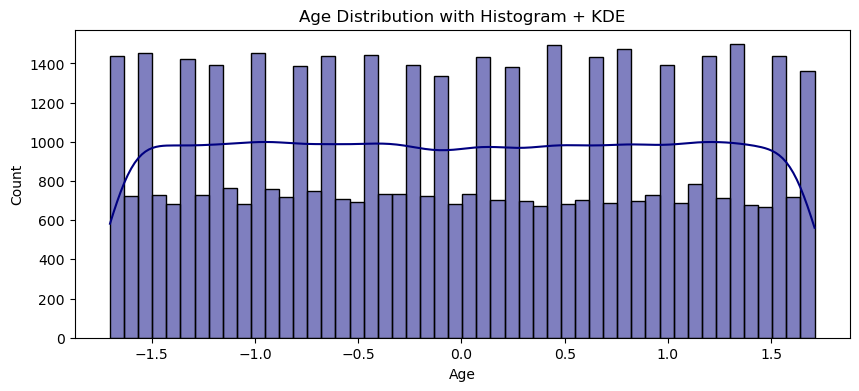

In [312]:
#Displaying Age distribution using Histplot with kde
plt.figure(figsize=(10,4))
sns.histplot(data=df, x='Age', bins=50, kde=True, color='navy')
plt.xlabel('Age')
plt.title('Age Distribution with Histogram + KDE');

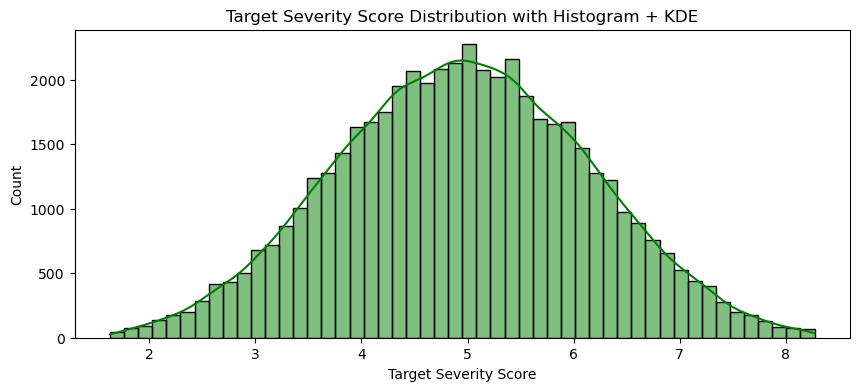

In [313]:
#Displaying Target Severity Score Distribution using Histplot with kde
plt.figure(figsize=(10,4))
sns.histplot(data=df, x='Target_Severity_Score', bins=50, kde=True, color='green')
plt.xlabel('Target Severity Score')
plt.title('Target Severity Score Distribution with Histogram + KDE');

In [314]:
# To understand most common Cancer_Type
plt.figure(figsize=(12,4))
Cancer_Type = ['Cancer_Type_Cervical', 'Cancer_Type_Colon',
       'Cancer_Type_Leukemia', 'Cancer_Type_Liver', 'Cancer_Type_Lung',
       'Cancer_Type_Prostate', 'Cancer_Type_Skin']
cancer_counts = df[Cancer_Type].sum()

<Figure size 1200x400 with 0 Axes>

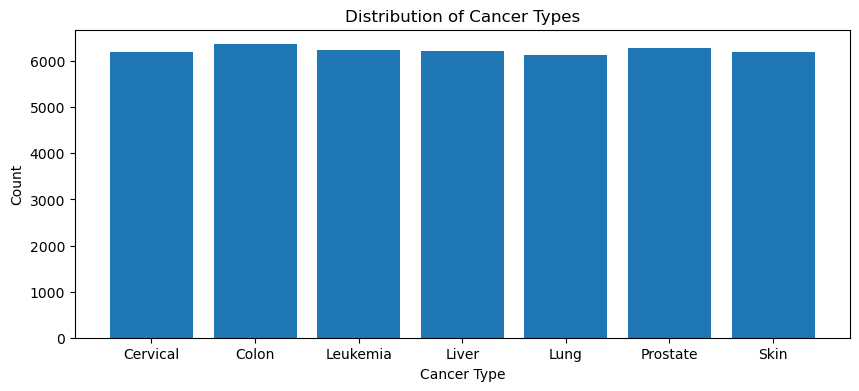

In [315]:
cancer_counts.index = cancer_counts.index.str.replace("Cancer_Type_", "")
plt.figure(figsize=(10,4))
plt.bar(cancer_counts.index, cancer_counts.values)
plt.title("Distribution of Cancer Types")
plt.xlabel("Cancer Type")
plt.ylabel("Count")
plt.show()

<h3>Step-8: Bivariate & Multivariate EDA</h3>

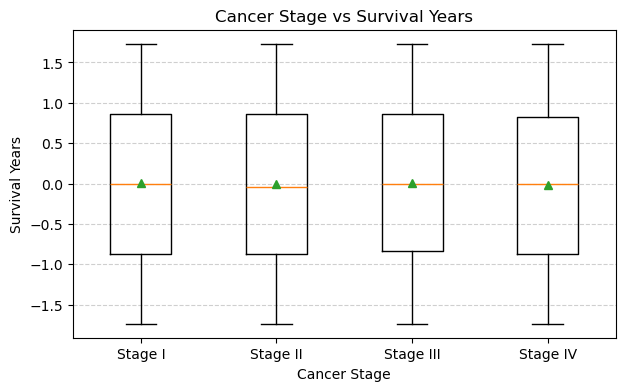

In [317]:
#How Cancer_Stage affect Survival_Years
plt.figure(figsize=(7,4))
plt.boxplot([
    df[df['Cancer_Stage_Stage I'] == 1]['Survival_Years'],
    df[df['Cancer_Stage_Stage II'] == 1]['Survival_Years'],
    df[df['Cancer_Stage_Stage III'] == 1]['Survival_Years'],
    df[df['Cancer_Stage_Stage IV'] == 1]['Survival_Years']
],
tick_labels=['Stage I', 'Stage II', 'Stage III', 'Stage IV'],showmeans=True)

plt.title("Cancer Stage vs Survival Years")
plt.xlabel("Cancer Stage")
plt.ylabel("Survival Years")
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

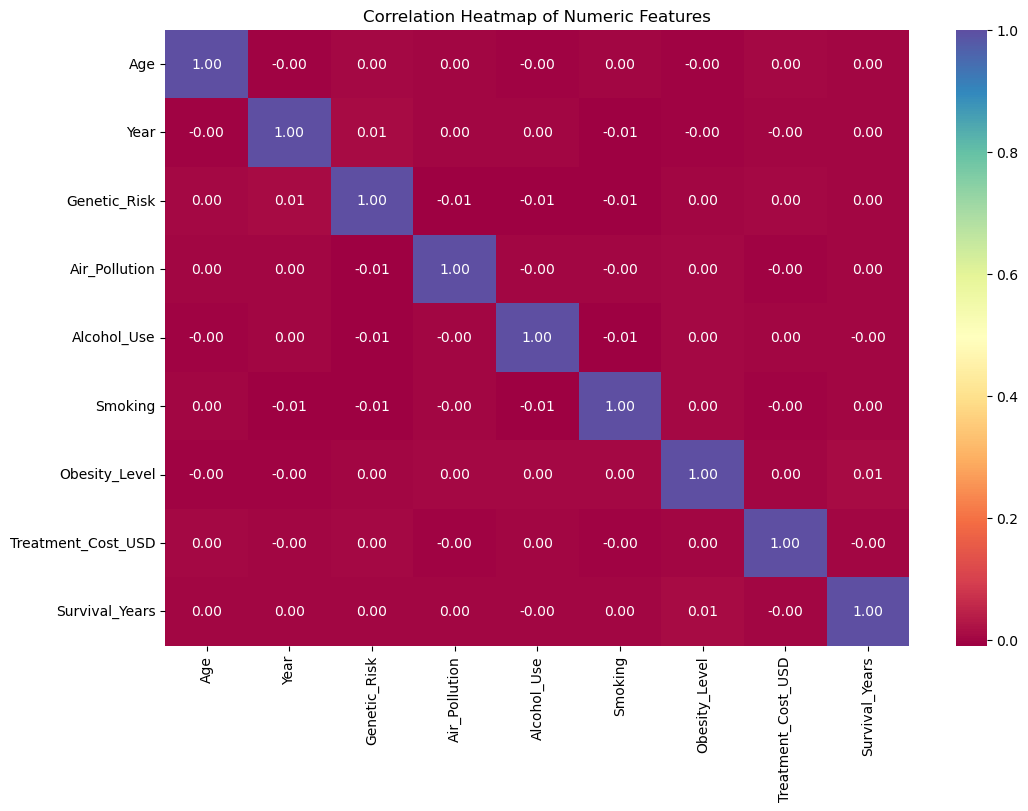

In [318]:
#Displaying features correlate with severity using HeatMap
corr_matrix = df[num_cols].corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="Spectral")
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

<h3>Step-9: Insights & Conclusion</h3>

#### The top 8 insights from the data
1. Smoking shows the highest positive correlation with Target_Severity_Score.Patients who smokes more are likely to have high Target_Severity_Score value.
2. Patients with higher genetic risk scores tend to have higher severity scores.
3. The dataset shows a strong positive relationship between air pollution exposure and Target_Severity_Score.
4. Higher alcohol consumption refers increased cancer severity.
5. Obesity shows a noticeable correlation with severity.
6. Higher treatment costs tend to be have lower severity scores which indicates that expensive treatments helps to improve patient's condition.
7. Mostly there is no correlation between Survival_Years and Target_Severity_Score
8. There is no or zero correlation between patient age or year with Cancer severity. 

#### columns influence severity and survival
1. Smoking, Genetic_Risk, Air_Pollution, Alcohol_Use, and Obesity_Level strongly influence Cancer Severity.
2. Survival year has very low correlation with other columns.
3. No feature in the dataset can strongly predict the survival rates.
4. Additional features like treatment type, patient history are required to predict survival rates.